# Χωρική Πρόβλεψη Χρόνων Αναμονής Τμήματος Επειγόντων Περιστατικών σε Δίκτυο Παρόχου με την PROC KRIGE2D

## Περίληψη για τη Διοίκηση

Μια ομάδα λειτουργιών δικτύου συστήματος υγείας μετρά τον μέσο χρόνο αναμονής στο Τμήμα Επειγόντων Περιστατικών (ΤΕΠ) (σε λεπτά) σε κάθε στελεχωμένη εγκατάσταση μιας μητροπολιτικής περιοχής κάλυψης και θέλει μια συνεχή επιφάνεια χρόνου αναμονής για να εντοπίσει ανεπαρκώς καλυμμένα κενά για μια νέα μονάδα επειγόντων περιστατικών. Αυτό το notebook δημιουργεί ένα συνθετικό σύνολο **90 γεωκωδικοποιημένων εγκαταστάσεων**, προσαρμόζει ένα μοντέλο **απλής κριγκίνγκ (ordinary kriging)** με nugget, και παρεμβάλλει τους χρόνους αναμονής ΤΕΠ σε ένα κανονικό πλέγμα που καλύπτει την περιοχή κάλυψης 50 km x 50 km, παράγοντας σημειακές προβλέψεις και τυπικά σφάλματα κριγκίνγκ σε κάθε κόμβο πλέγματος και σε τρεις προτεινόμενες θέσεις επειγόντων περιστατικών.

Στις 90 εγκαταστάσεις ο παρατηρούμενος χρόνος αναμονής έχει μέσο όρο **35,5 λεπτά** (εύρος 7,5 έως 58,7). Η επιφάνεια κριγκίνγκ αναπαράγει σχεδόν ακριβώς αυτό το κέντρο (μέσος όρος κόμβων πλέγματος **35,55 λεπτά**) και κυμαίνεται από **16,1** στη ήσυχη νοτιοανατολική περιοχή έως **56,4** στη συμφορημένη βορειοδυτική περιοχή, όπου συγκεντρώνονται οι κόμβοι με τους υψηλότερους προβλεπόμενους χρόνους αναμονής γύρω από την έξαρση του κέντρου της πόλης. Από τις τρεις υποψήφιες θέσεις επειγόντων περιστατικών, αυτή που βρίσκεται πλησιέστερα στο κέντρο της πόλης προβλέπει τον υψηλότερο χρόνο αναμονής (**52,2 +/- 7,3 λεπτά**), αποτελώντας την ισχυρότερη τεκμηριωμένη περίπτωση επιλογής θέσης.

## Πηγές Δεδομένων

Όλα τα δεδομένα είναι συνθετικά και δημιουργούνται εν σειρά στο πρώτο βήμα ΔΕΔΟΜΕΝΑ (`call streaminit(20260531)`). Δεν χρησιμοποιούνται εξωτερικά αρχεία ή αρχεία δικτύου.

| Σύνολο Δεδομένων | Γραμμές | Μεταβλητή | Τύπος | Περιγραφή |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | Αριθμός | Ανατολική συντεταγμένη εγκατάστασης σε km (0-50) εντός του μητροπολιτικού πλέγματος κάλυψης |
| `ed_sites` | 90 | `north` | Αριθμός | Βόρεια συντεταγμένη εγκατάστασης σε km (0-50) εντός του μητροπολιτικού πλέγματος κάλυψης |
| `ed_sites` | 90 | `site_id` | Χαρακτήρας | Αναγνωριστικό εγκατάστασης (π.χ. `FAC037`) |
| `ed_sites` | 90 | `wait_min` | Αριθμός | Παρατηρούμενος μέσος χρόνος αναμονής ΤΕΠ σε λεπτά· μια χωρικά συσχετισμένη επιφάνεια που συνδυάζει μια κλίση συμφόρησης ΒΔ-ΝΑ, μια έξαρση στο κέντρο της πόλης, και τοπικό θόρυβο |

## Χωρική Πρόβλεψη Χρόνων Αναμονής ΤΕΠ με την PROC KRIGE2D

Ένα περιφερειακό σύστημα υγείας στελεχώνει **τμήματα επειγόντων περιστατικών και κλινικές επειγουσών περιπτώσεων** διάσπαρτες σε μια μητροπολιτική περιοχή κάλυψης 50 km x 50 km. Κάθε εγκατάσταση αναφέρει τον **μέσο χρόνο αναμονής ΤΕΠ** (σε λεπτά). Οι χρόνοι αναμονής είναι χωρικά συσχετισμένοι: ο συμφορημένος αστικός πυρήνας στα βορειοδυτικά έχει υψηλές τιμές, ενώ οι περιφερειακές εγκαταστάσεις στα νοτιοανατολικά έχουν χαμηλότερες. Ο σχεδιασμός δικτύου θέλει μια *συνεχή* επιφάνεια χρόνου αναμονής, με αβεβαιότητα, για να εντοπίσει κενά όπου μια νέα μονάδα επειγόντων περιστατικών θα ανακούφιζε τη μεγαλύτερη πίεση.

Η **PROC KRIGE2D** εκτελεί δισδιάστατη απλή κριγκίνγκ: χρησιμοποιεί ένα μοντέλο ημι-διακύμανσης (semivariogram) για να παρεμβάλει τους μετρημένους χρόνους αναμονής σε ένα πλέγμα θέσεων, επιστρέφοντας τόσο μια πρόβλεψη όσο και ένα τυπικό σφάλμα κριγκίνγκ σε κάθε κόμβο. Θα:

1. Δημιουργήσουμε ένα ρεαλιστικό συνθετικό σύνολο δεδομένων εγκαταστάσεων.
2. Κάνουμε προφίλ της παρατηρούμενης κατανομής χρόνου αναμονής.
3. Εφαρμόσουμε κριγκίνγκ με σφαιρικό μοντέλο συν nugget και εξετάσουμε την επιφάνεια.
4. Προβλέψουμε απευθείας σε τρεις υποψήφιες θέσεις επειγόντων περιστατικών.

## Βήμα 1 - Δημιουργία συνθετικών δεδομένων εγκαταστάσεων

Διασπείρουμε 90 εγκαταστάσεις ομοιόμορφα σε όλη την περιοχή κάλυψης. Η υποκείμενη "πραγματική" επιφάνεια χρόνου αναμονής συνδυάζει μια ομαλή τάση μεγάλης κλίμακας (μια κλίση συμφόρησης ΒΔ-προς-ΝΑ συν μια κεντρική έξαρση κοντά στο (15, 38)) με μια ομαλή περιφερειακή δίνη, ώστε το πεδίο να είναι πραγματικά χωρικά αυτοσυσχετισμένο και όχι απλός θόρυβος. Προσθέτουμε ένα μικρό nugget μέτρησης για να προσομοιώσουμε την ημερήσια διακύμανση αναφοράς.

In [1]:
ΔΕΔΟΜΕΝΑ ed_sites;
   CALL streaminit(20260531);
   LENGTH site_id $6;
   ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* Τάση συμφόρησης μεγάλης κλίμακας: υψηλή στον αστικό πυρήνα ΒΔ,
         μειούμενη προς το προαστιακό άκρο ΝΑ */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* Κεντρική έξαρση κέντρου πόλης γύρω από (15, 38) */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* Ομαλή περιφερειακή δίνη για ρεαλιστική αυτοσυσχέτιση */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* Τοπικός θόρυβος αναφοράς (nugget μέτρησης) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      ΕΑΝ wait_min < 3 ΤΟΤΕ wait_min = 3;

      site_id = cats('FAC', PUT(i, z3.));
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
   ΚΡΑΤΗΣΗ site_id east north wait_min;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=ed_sites(obs=10) noobs ΕΤΙΚΕΤΑ;
   ΕΤΙΚΕΤΑ site_id='Αναγνωριστικό Εγκατάστασης' east='Ανατολικά (km)'
         north='Βόρεια (km)' wait_min='Χρόνος Αναμονής (λεπτά)';
   TITLE 'Πρώτες 10 Συνθετικές Εγκαταστάσεις ΤΕΠ (συντεταγμένες σε km, αναμονή σε λεπτά)';
   ΜΕΤΑΒΛΗΤΗ site_id east north wait_min;
ΕΚΤΕΛΕΣΗ;

                     Πρώτες 10 Συνθετικές Εγκαταστάσεις ΤΕΠ (συντεταγμένες σε km, αναμονή σε λεπτά)                     

                         Αναγνωριστικό Εγκατάστασης           Ανατολικά (km)        Βόρεια (km)                     Χρόνος Αναμονής (λεπτά)
FAC001                                                         42.1064239035      44.8746335392                                        36.7
FAC002                                                         10.6189061789      14.5101311244                                        36.2
FAC003                                                         48.9064287162        18.61727984                                        17.7
FAC004                                                          45.555283186       43.264675772                                        34.5
FAC005                                                         32.9816533373      24.7120124541                                        32.5
FAC006                                


NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Βήμα 2 - Προφίλ των παρατηρούμενων χρόνων αναμονής

Πριν από την κριγκίνγκ, επιβεβαιώνουμε ότι η επιφάνεια κατανέμεται λογικά. Μια γρήγορη σύνοψη `PROC MEANS` μας δίνει το εύρος και την κεντρική τάση που θα πρέπει να αναπαράγει η επιφάνεια κριγκίνγκ. Οι 90 εγκαταστάσεις έχουν μέσο όρο **35,5 λεπτά** με τυπική απόκλιση **10,6**, εκτεινόμενες από **7,5** στην πιο ήσυχη περιφερειακή εγκατάσταση έως **58,7** στην πιο συμφορημένη εγκατάσταση του κέντρου της πόλης - ένα ευρύ, ρεαλιστικό εύρος για έναν στόχο παρεμβολής.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   ΕΤΙΚΕΤΑ wait_min='Χρόνος Αναμονής (λεπτά)';
   TITLE 'Παρατηρούμενη Κατανομή Χρόνου Αναμονής ΤΕΠ ανά Εγκατάσταση';
   ΜΕΤΑΒΛΗΤΗ wait_min;
ΕΚΤΕΛΕΣΗ;

                               Παρατηρούμενη Κατανομή Χρόνου Αναμονής ΤΕΠ ανά Εγκατάσταση                               

                                                  The MEANS Procedure

 Variable  Label                                             N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------------------------------------------
 wait_min  Χρόνος Αναμονής (λεπτά)                          90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 -----------------------------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Βήμα 3 - Απλή κριγκίνγκ με σφαιρικό μοντέλο

Η δήλωση `COORDINATES` ονομάζει τους χωρικούς άξονες, το `PREDICT VAR=` ονομάζει τη μεταβλητή ανάλυσης και ορίζει τη γειτονιά αναζήτησης, και το `MODEL` παρέχει το ημι-διακυμανόγραμμα. Χρησιμοποιούμε **σφαιρική** μορφή (μια τυπική επιλογή όταν η συσχέτιση μηδενίζεται σε πεπερασμένο εύρος), με:

- `SCALE=120` - το μερικό sill (διακύμανση που εξηγείται από τη χωρική δομή),
- `RANGE=18` - η συσχέτιση φτάνει στο υπόβαθρο σε περίπου 18 km,
- `NUGGET=14` - η ασυνέχεια μέτρησης/αναφοράς σε μηδενική απόσταση.

Παρεμβάλλουμε σε ένα κανονικό πλέγμα **9 x 9 = 81 κόμβων** που καλύπτει ολόκληρη την περιοχή κάλυψης (`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - αρκετά αδρό ώστε να συνοψίζουμε και να κατατάσσουμε κάθε κόμβο απευθείας, αρκετά λεπτό ώστε να χαρτογραφούμε τη δομή. Το `OUTEST=` καταγράφει τις προβλέψεις και τα τυπικά σφάλματα του πλέγματος· το `OUTNBHD=` καταγράφει πόσες εγκαταστάσεις εισήλθαν σε κάθε τοπική επίλυση. Το `PLOTS=` ζητά τον χάρτη παρατηρούμενων δεδομένων και το contour πρόβλεψης γεμισμένο με τυπικό σφάλμα.

                               Παρατηρούμενη Κατανομή Χρόνου Αναμονής ΤΕΠ ανά Εγκατάσταση                               

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


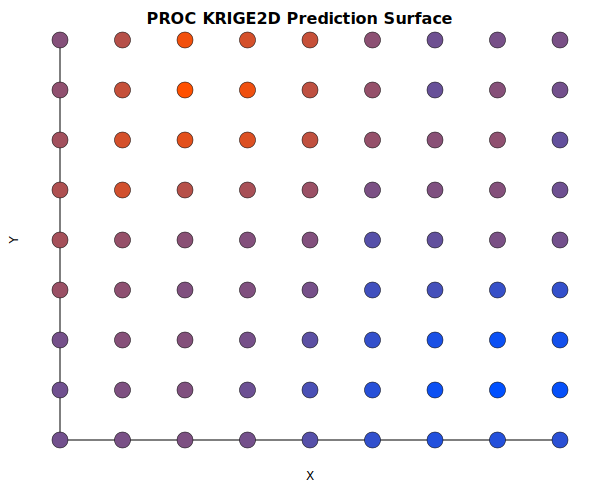

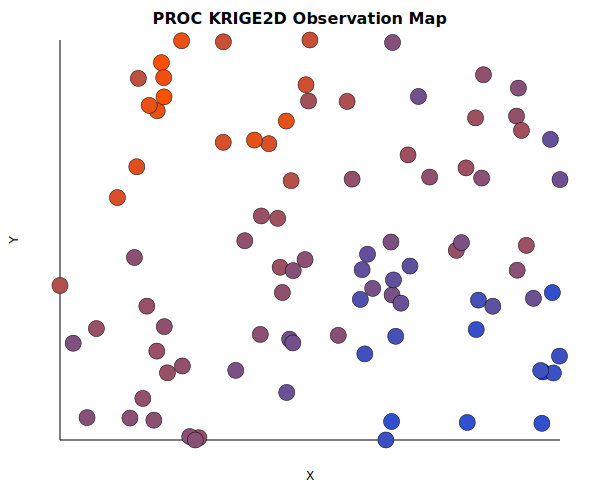

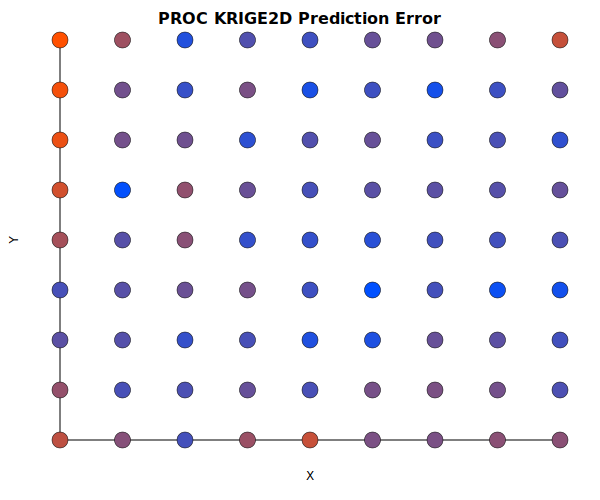

In [3]:
ΔΙΑΔΙΚΑΣΙΑ krige2d ΔΕΔΟΜΕΝΑ=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   TITLE 'Απλή Κριγκίνγκ Χρόνων Αναμονής ΤΕΠ - Σφαιρικό Μοντέλο';
   ΕΤΙΚΕΤΑ east='Ανατολικά (km)' north='Βόρεια (km)' wait_min='Χρόνος Αναμονής (λεπτά)';
   COORDINATES XC=east YC=north;
   predict ΜΕΤΑΒΛΗΤΗ=wait_min radius=20 minpoints=10 maxpoints=40;
   ΜΟΝΤΕΛΟ FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 ΕΩΣ 50 ΚΑΤΑ 6 y=0 ΕΩΣ 50 ΚΑΤΑ 6;
ΕΚΤΕΛΕΣΗ;

## Βήμα 4 - Εξέταση της επιφάνειας κριγκίνγκ

Το σύνολο δεδομένων `OUTEST=` κρατά μία γραμμή ανά κόμβο πλέγματος με τον προβλεπόμενο χρόνο αναμονής (`estimate`) και το τυπικό σφάλμα κριγκίνγκ (`stderr`). Συνοψίζουμε την επιφάνεια και επισημαίνουμε τους πιο "καυτούς" προβλεπόμενους κόμβους - υποψήφιες ζώνες όπου μια νέα μονάδα επειγόντων περιστατικών θα ανακούφιζε τη μεγαλύτερη πίεση.

Ο μέσος όρος της επιφάνειας κριγκίνγκ (**35,55 λεπτά**) ακολουθεί σχεδόν ακριβώς τον παρατηρούμενο μέσο όρο εγκαταστάσεων (35,5), έναν έλεγχο λογικής ότι η απλή κριγκίνγκ είναι αμερόληπτη. Οι προβλέψεις κυμαίνονται από **16,1** στη αραιά νοτιοανατολική περιοχή έως **56,4** στη συμφορημένη βορειοδυτική περιοχή· τα τυπικά σφάλματα κυμαίνονται από **5,1** όπου οι εγκαταστάσεις είναι πυκνές έως **11,2** σε αραιά δειγματοληπτημένες γωνίες. Οι έξι πιο "καυτοί" κόμβοι βρίσκονται όλοι στο ΒΔ τεταρτημόριο γύρω από (12-18, 36-48), ακριβώς πάνω στην έξαρση του κέντρου της πόλης που είναι ενσωματωμένη στα δεδομένα.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=krige_sph n mean MIN MAX maxdec=2;
   ΕΤΙΚΕΤΑ ESTIMATE='Εκτίμηση Αναμονής (λεπτά)' stderr='Τυπικό Σφάλμα';
   TITLE 'Σύνοψη Επιφάνειας Kriging (Προβλεπόμενα Λεπτά Αναμονής και Τυπικό Σφάλμα)';
   ΜΕΤΑΒΛΗΤΗ ESTIMATE stderr;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=krige_sph out=hot_nodes;
   ΚΑΤΑ DESCENDING ESTIMATE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=hot_nodes(obs=6) noobs ΕΤΙΚΕΤΑ;
   ΕΤΙΚΕΤΑ x='X (km)' y='Y (km)' ESTIMATE='Εκτίμηση Αναμονής (λεπτά)' stderr='Τυπικό Σφάλμα';
   TITLE 'Έξι Κόμβοι Πλέγματος με τους Υψηλότερους Προβλεπόμενους Χρόνους Αναμονής ΤΕΠ';
   ΜΕΤΑΒΛΗΤΗ x y ESTIMATE stderr;
ΕΚΤΕΛΕΣΗ;

                       Σύνοψη Επιφάνειας Kriging (Προβλεπόμενα Λεπτά Αναμονής και Τυπικό Σφάλμα)                        

                                                  The MEANS Procedure

 Variable  Label                                                 N        Mean     Minimum     Maximum
 -----------------------------------------------------------------------------------------------------
 ESTIMATE  Εκτίμηση Αναμονής (λεπτά)                            81       35.55       16.07       56.38
 STDERR    Τυπικό Σφάλμα                                        81        7.38        5.06       11.20
 -----------------------------------------------------------------------------------------------------

                      Έξι Κόμβοι Πλέγματος με τους Υψηλότερους Προβλεπόμενους Χρόνους Αναμονής ΤΕΠ                      

X (km)  Y (km)                       Εκτίμηση Αναμονής (λεπτά)              Τυπικό Σφάλμα
    12      42                                   56.3838526129               6.


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Βήμα 5 - Πρόβλεψη σε συγκεκριμένες υποψήφιες θέσεις

Ο σχεδιασμός δικτύου έχει τρεις προτεινόμενες θέσεις επειγουσών περιπτώσεων. Εφαρμόζουμε κριγκίνγκ απευθείας σε κάθε σημείο παρέχοντάς το ως ένα πλέγμα ενός κόμβου (`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`), δίνοντας στους σχεδιαστές τον προβλεπόμενο χρόνο αναμονής και το τυπικό του σφάλμα κριγκίνγκ στη ακριβή συντεταγμένη.

Η υποψήφια θέση κοντά στο κέντρο της πόλης, **(14, 37)**, επιστρέφει τον υψηλότερο προβλεπόμενο χρόνο αναμονής - **52,2 +/- 7,3 λεπτά** - επιβεβαιώνοντας ότι θα απορροφούσε ζήτηση από τα πιο πολυσύχναστα ΤΕΠ. Η νοτιοανατολική υποψήφια θέση **(32, 12)** βρίσκεται στην ήσυχη περιφερειακή γωνία με **22,0 +/- 6,2**, και η βορειοανατολική υποψήφια θέση **(42, 44)** βρίσκεται σε ενδιάμεσο επίπεδο με **36,4 +/- 5,9**. Με βάση μόνο τον προβλεπόμενο χρόνο αναμονής, η υποψήφια θέση στο κέντρο της πόλης αποτελεί την ισχυρότερη τεκμηριωμένη περίπτωση επιλογής θέσης.

In [5]:
ΔΙΑΔΙΚΑΣΙΑ krige2d ΔΕΔΟΜΕΝΑ=ed_sites outest=cand_dt PLOTS=none;
   TITLE 'Υποψήφια Θέση Α - Κέντρο Πόλης (14, 37)';
   COORDINATES XC=east YC=north;
   predict ΜΕΤΑΒΛΗΤΗ=wait_min radius=20 minpoints=8 maxpoints=40;
   ΜΟΝΤΕΛΟ FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 ΕΩΣ 14 ΚΑΤΑ 1 y=37 ΕΩΣ 37 ΚΑΤΑ 1;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ krige2d ΔΕΔΟΜΕΝΑ=ed_sites outest=cand_se PLOTS=none;
   TITLE 'Υποψήφια Θέση Β - Νοτιοανατολικά Προάστια (32, 12)';
   COORDINATES XC=east YC=north;
   predict ΜΕΤΑΒΛΗΤΗ=wait_min radius=20 minpoints=8 maxpoints=40;
   ΜΟΝΤΕΛΟ FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 ΕΩΣ 32 ΚΑΤΑ 1 y=12 ΕΩΣ 12 ΚΑΤΑ 1;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ krige2d ΔΕΔΟΜΕΝΑ=ed_sites outest=cand_ne PLOTS=none;
   TITLE 'Υποψήφια Θέση Γ - Βορειοανατολικό Άκρο (42, 44)';
   COORDINATES XC=east YC=north;
   predict ΜΕΤΑΒΛΗΤΗ=wait_min radius=20 minpoints=8 maxpoints=40;
   ΜΟΝΤΕΛΟ FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 ΕΩΣ 42 ΚΑΤΑ 1 y=44 ΕΩΣ 44 ΚΑΤΑ 1;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ candidates;
   ΟΡΙΣΜΟΣ cand_dt cand_se cand_ne;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=candidates noobs ΕΤΙΚΕΤΑ;
   ΕΤΙΚΕΤΑ x='X (km)' y='Y (km)' ESTIMATE='Εκτίμηση Αναμονής (λεπτά)' stderr='Τυπικό Σφάλμα';
   TITLE 'Προβλεπόμενοι Χρόνοι Αναμονής ΤΕΠ σε Τρεις Υποψήφιες Θέσεις Επειγόντων Περιστατικών';
   ΜΕΤΑΒΛΗΤΗ x y ESTIMATE stderr;
ΕΚΤΕΛΕΣΗ;

                      Έξι Κόμβοι Πλέγματος με τους Υψηλότερους Προβλεπόμενους Χρόνους Αναμονής ΤΕΠ                      

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                      Έξι Κόμβοι Πλέγματος με τους Υψηλότερους Προβλεπόμενους Χρόνους Αναμονής ΤΕΠ                      

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## Ερμηνεία των αποτελεσμάτων

- **Η επιφάνεια κριγκίνγκ αναπαράγει τη δομή συμφόρησης της περιοχής κάλυψης.** Το σφαιρικό μοντέλο απλής κριγκίνγκ παρεμβάλλει ένα ομαλό πεδίο χρόνου αναμονής του οποίου ο μέσος όρος κόμβων πλέγματος (35,55 λεπτά) ταιριάζει με τον παρατηρούμενο μέσο όρο εγκαταστάσεων (35,5 λεπτά), με τους υψηλότερους προβλεπόμενους χρόνους αναμονής - έως 56,4 λεπτά - συγκεντρωμένους στο ΒΔ τεταρτημόριο γύρω από την έξαρση του κέντρου της πόλης κοντά στο (15, 38) που ενσωματώσαμε στα συνθετικά δεδομένα. Αυτή η αντιστοιχία είναι ένας έλεγχος λογικής ότι το μοντέλο συμπεριφέρεται σωστά.
- **Τα τυπικά σφάλματα εντοπίζουν την εμπιστοσύνη.** Το τυπικό σφάλμα κριγκίνγκ κυμαίνεται από 5,1 λεπτά όπου οι εγκαταστάσεις είναι πυκνές έως 11,2 στις αραιά δειγματοληπτημένες γωνίες της περιοχής κάλυψης. Οι σχεδιαστές θα πρέπει να αντιμετωπίζουν με προσοχή τις προβλέψεις σε ζώνες με υψηλό `stderr`· αυτές είναι επίσης οι περιοχές όπου η προσθήκη μιας εγκατάστασης θα βελτίωνε περισσότερο τόσο τη μελλοντική κάλυψη όσο και τη μελλοντική μέτρηση.
- **Οι σημειακές προβλέψεις υποστηρίζουν αποφάσεις επιλογής θέσης.** Η εφαρμογή κριγκίνγκ απευθείας στις τρεις υποψήφιες θέσεις μετατρέπει την επιφάνεια σε έναν αξιοποιήσιμο πίνακα. Η υποψήφια θέση στο κέντρο της πόλης (14, 37) δείχνει τον υψηλότερο προβλεπόμενο χρόνο αναμονής (52,2 λεπτά) με μέτριο τυπικό σφάλμα (7,3), αποτελώντας την ισχυρότερη τεκμηριωμένη περίπτωση για μια νέα μονάδα επειγόντων περιστατικών ώστε να αποσυμφορήσει το πιο πολυσύχναστο ΤΕΠ· η νοτιοανατολική περιφερειακή υποψήφια θέση (32, 12) βρίσκεται σε μια γωνία χαμηλής ζήτησης (22,0 λεπτά) και η βορειοανατολική υποψήφια θέση στο άκρο (42, 44) είναι σε ενδιάμεσο επίπεδο (36,4 λεπτά).

Στην πράξη οι παράμετροι του ημι-διακυμανογράμματος (`SCALE`, `RANGE`, `NUGGET`) θα εκτιμούνταν εμπειρικά με την PROC VARIOGRAM και στη συνέχεια θα περνούσαν στην KRIGE2D - είτε ως ρητές τιμές όπως φαίνεται εδώ, είτε αυτόματα μέσω `RESTORE` από ένα item store της VARIOGRAM.